Install and Import Dependencies

In [1]:
import sys
!{sys.executable} -m pip install ultralytics

  Using cached ultralytics-8.4.37-py3-none-any.whl.metadata (39 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached polars-1.39.3-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached 

In [1]:
import os
from ultralytics import YOLO
from IPython.display import Image, display

Define your Dataset Configuration

Initialize the Model

In [2]:
model = YOLO("yolo11n.pt") 

print("Model initialized and ready for training.")

Model initialized and ready for training.


Start Trainig

In [6]:
# Train the model
# epochs: how many times the model sees the data (start with 50-100)
# imgsz: image size (standard is 640)
results = model.train(data="/home/boaz/my_project_folder/data.yaml", epochs=50, imgsz=640)

Ultralytics 8.4.37 🚀 Python-3.12.3 torch-2.11.0+cu130 CPU (AMD Ryzen 7 5800H with Radeon Graphics)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/boaz/my_project_folder/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

Validate and Check Results

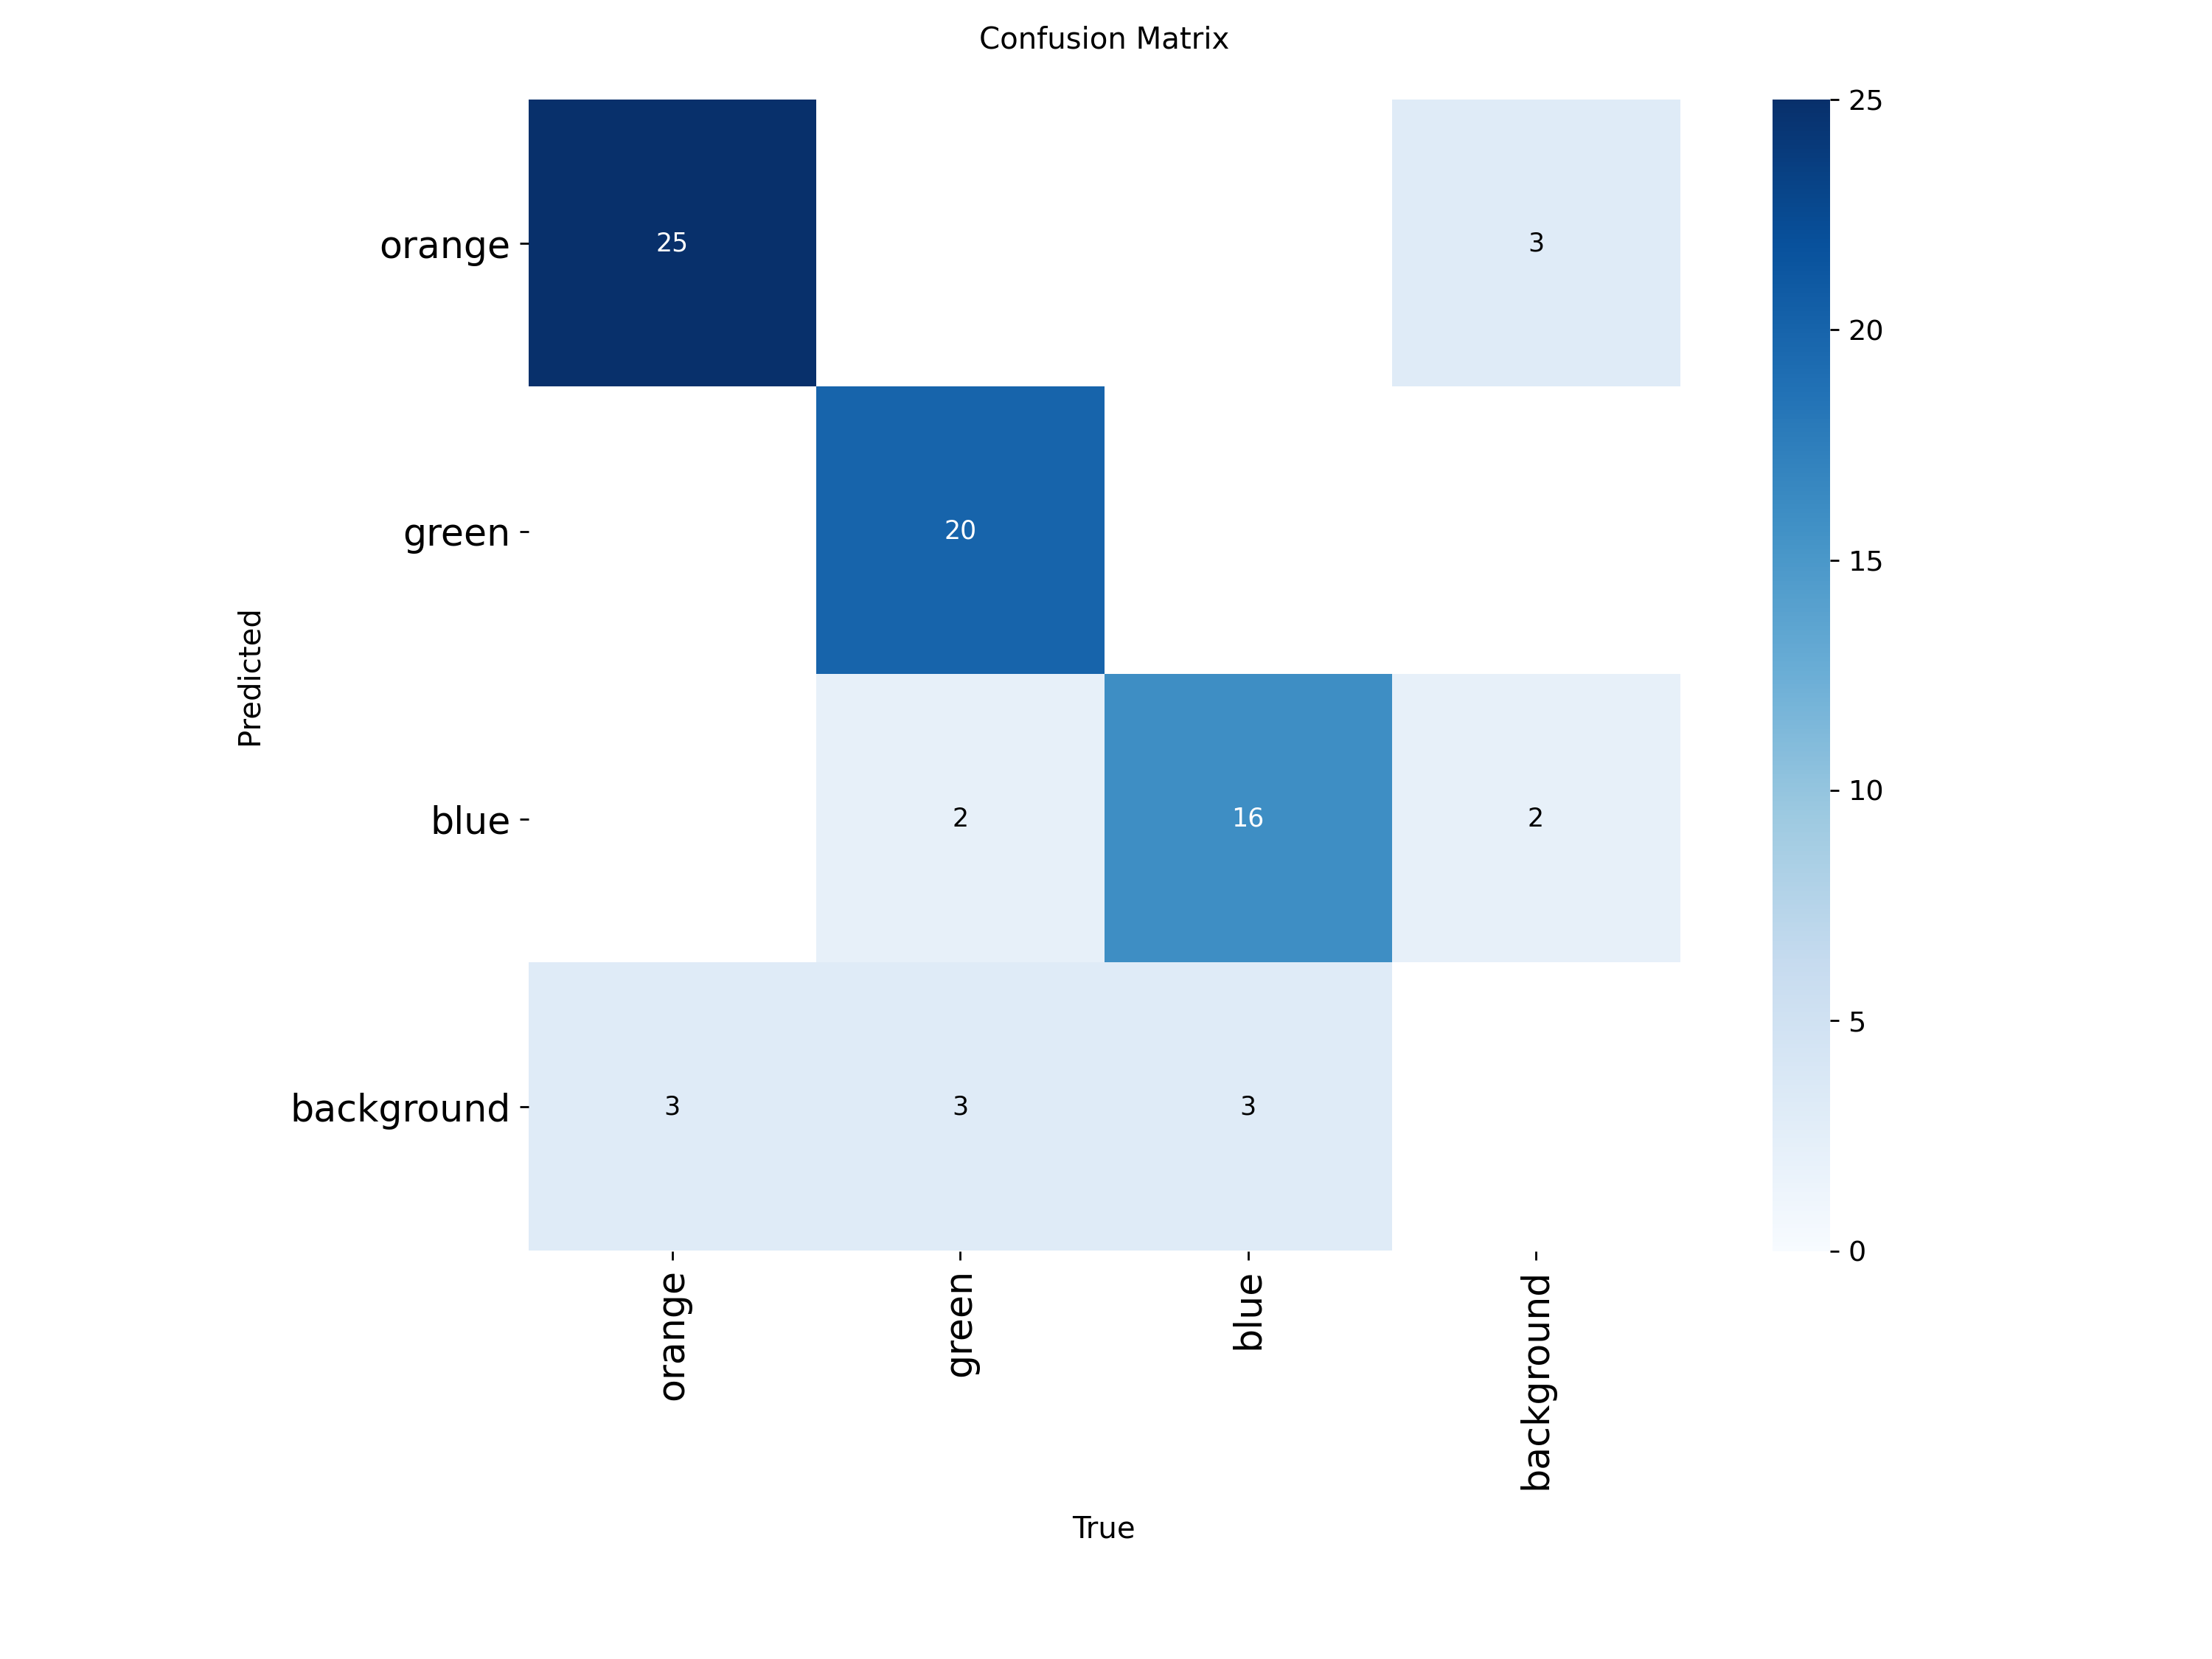

--- Ground Truth (Your Labels) ---


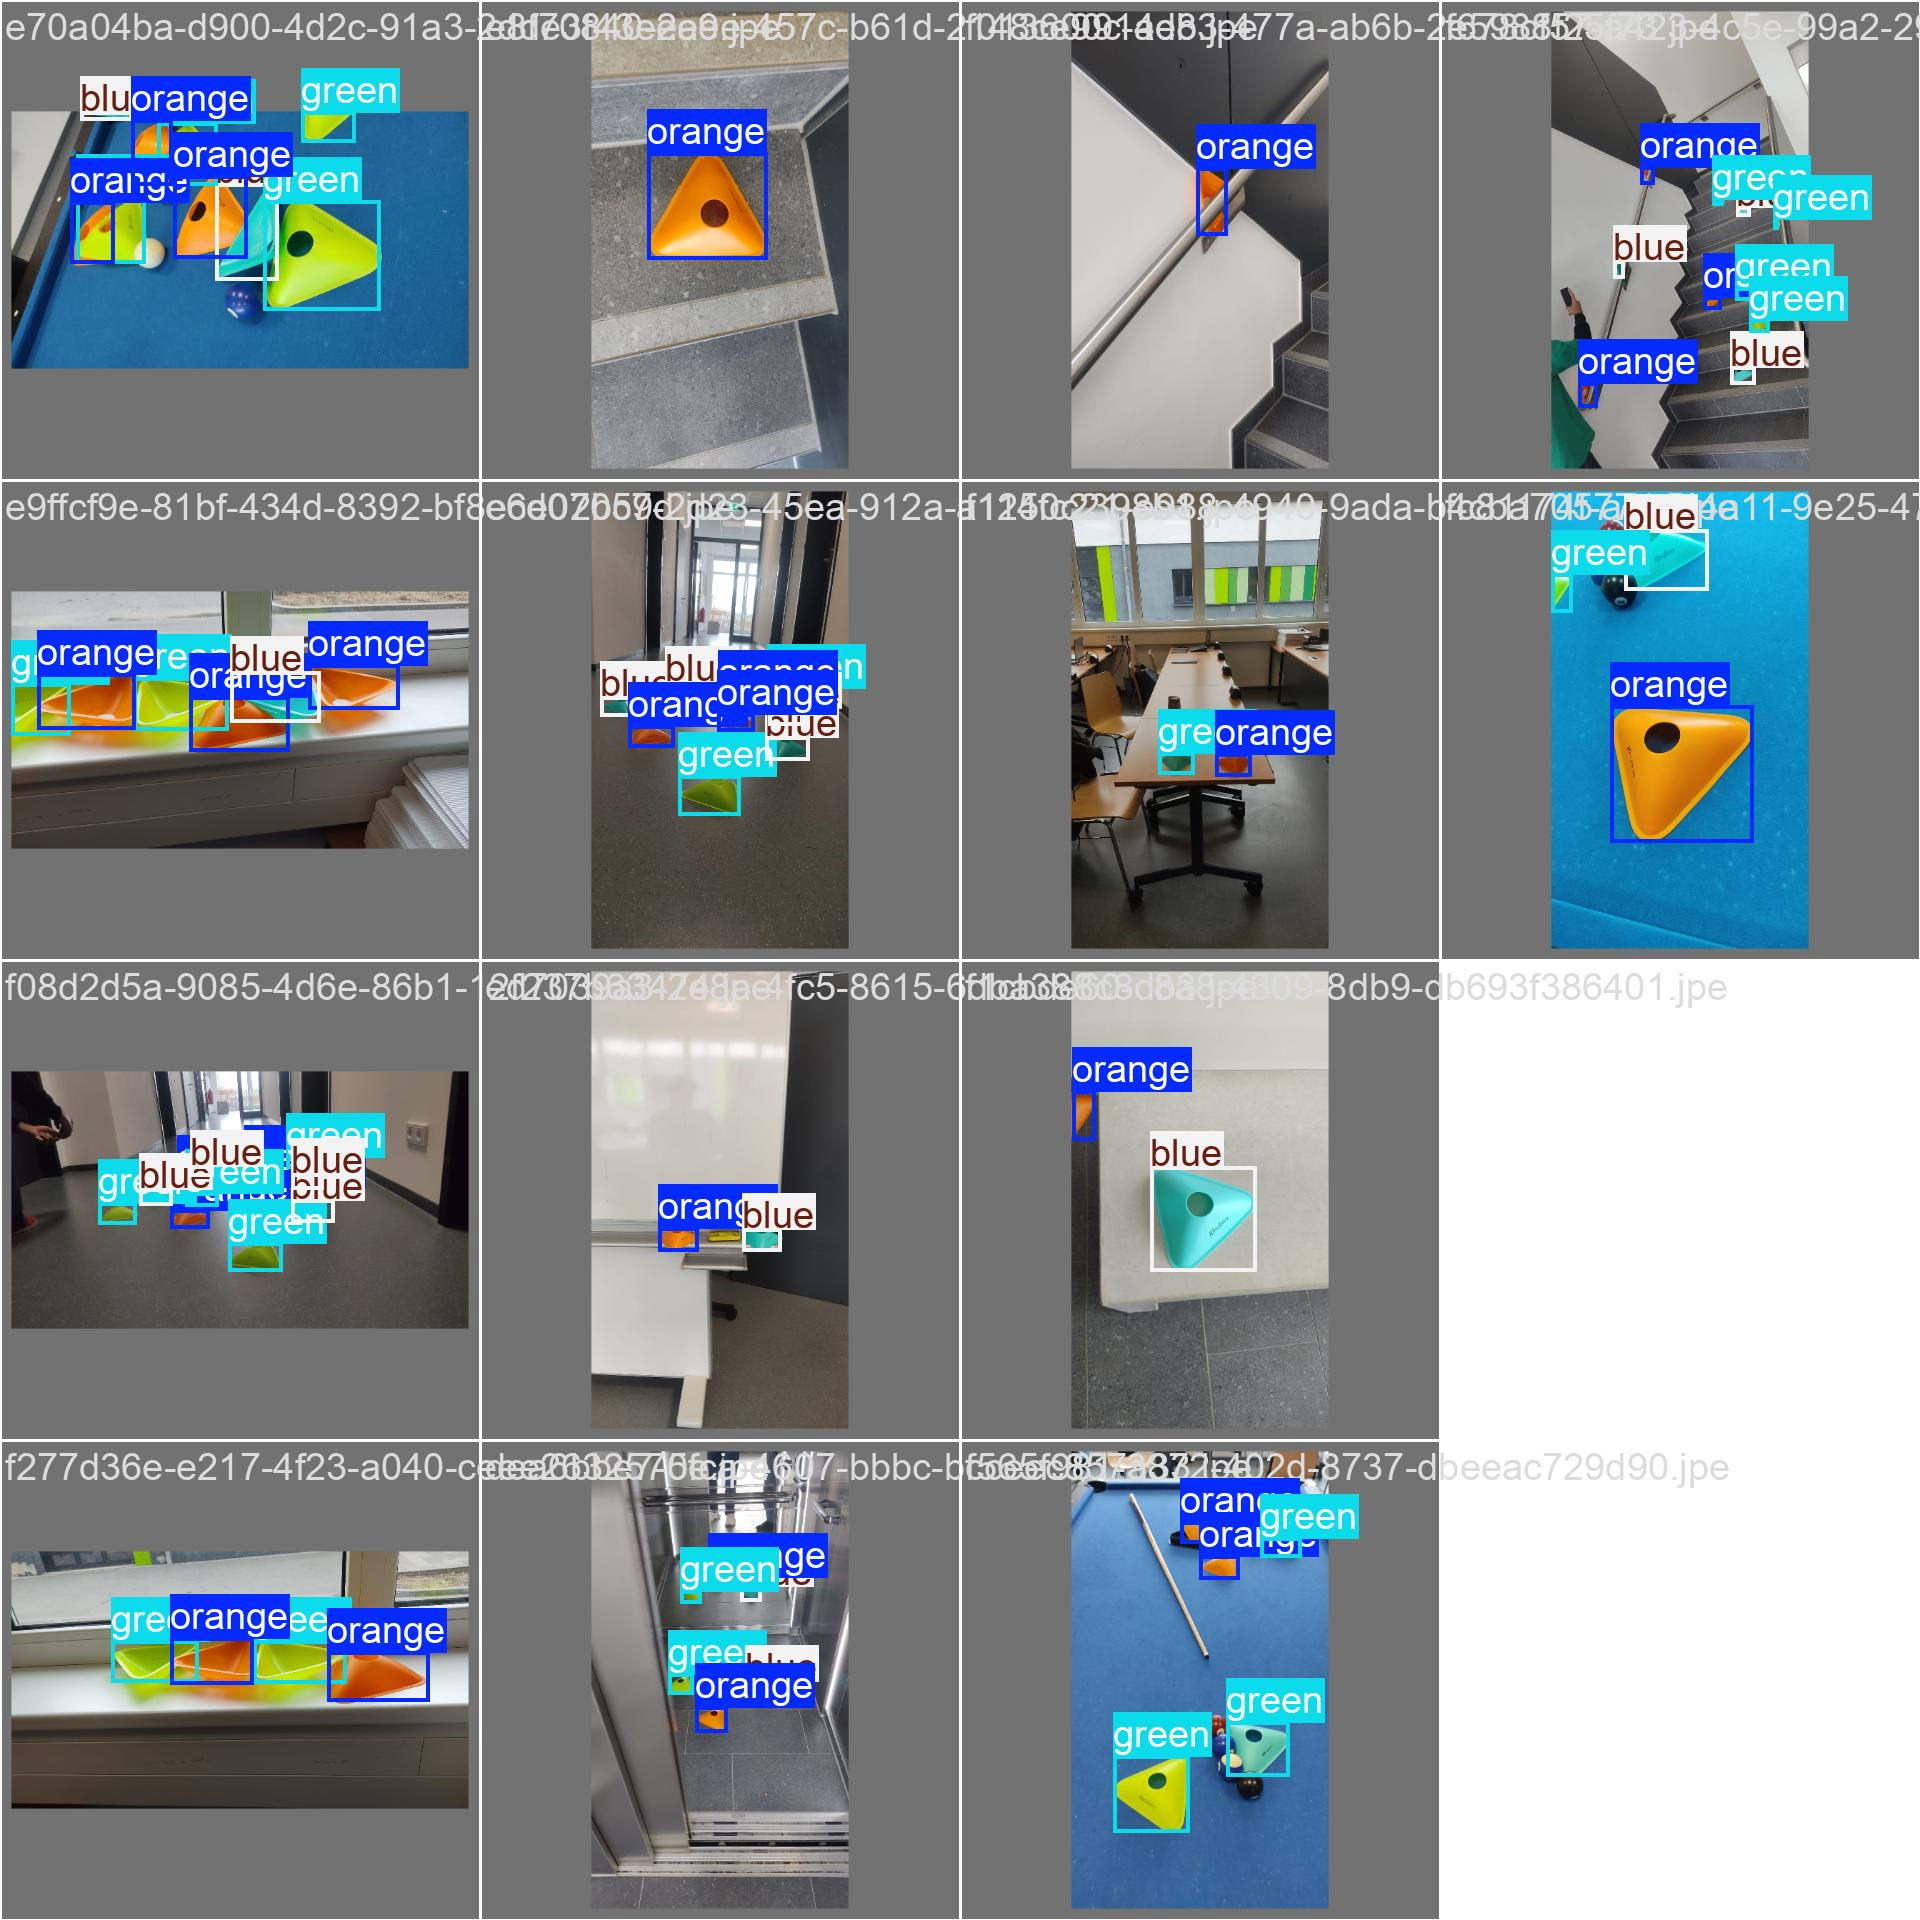


--- Model Predictions ---


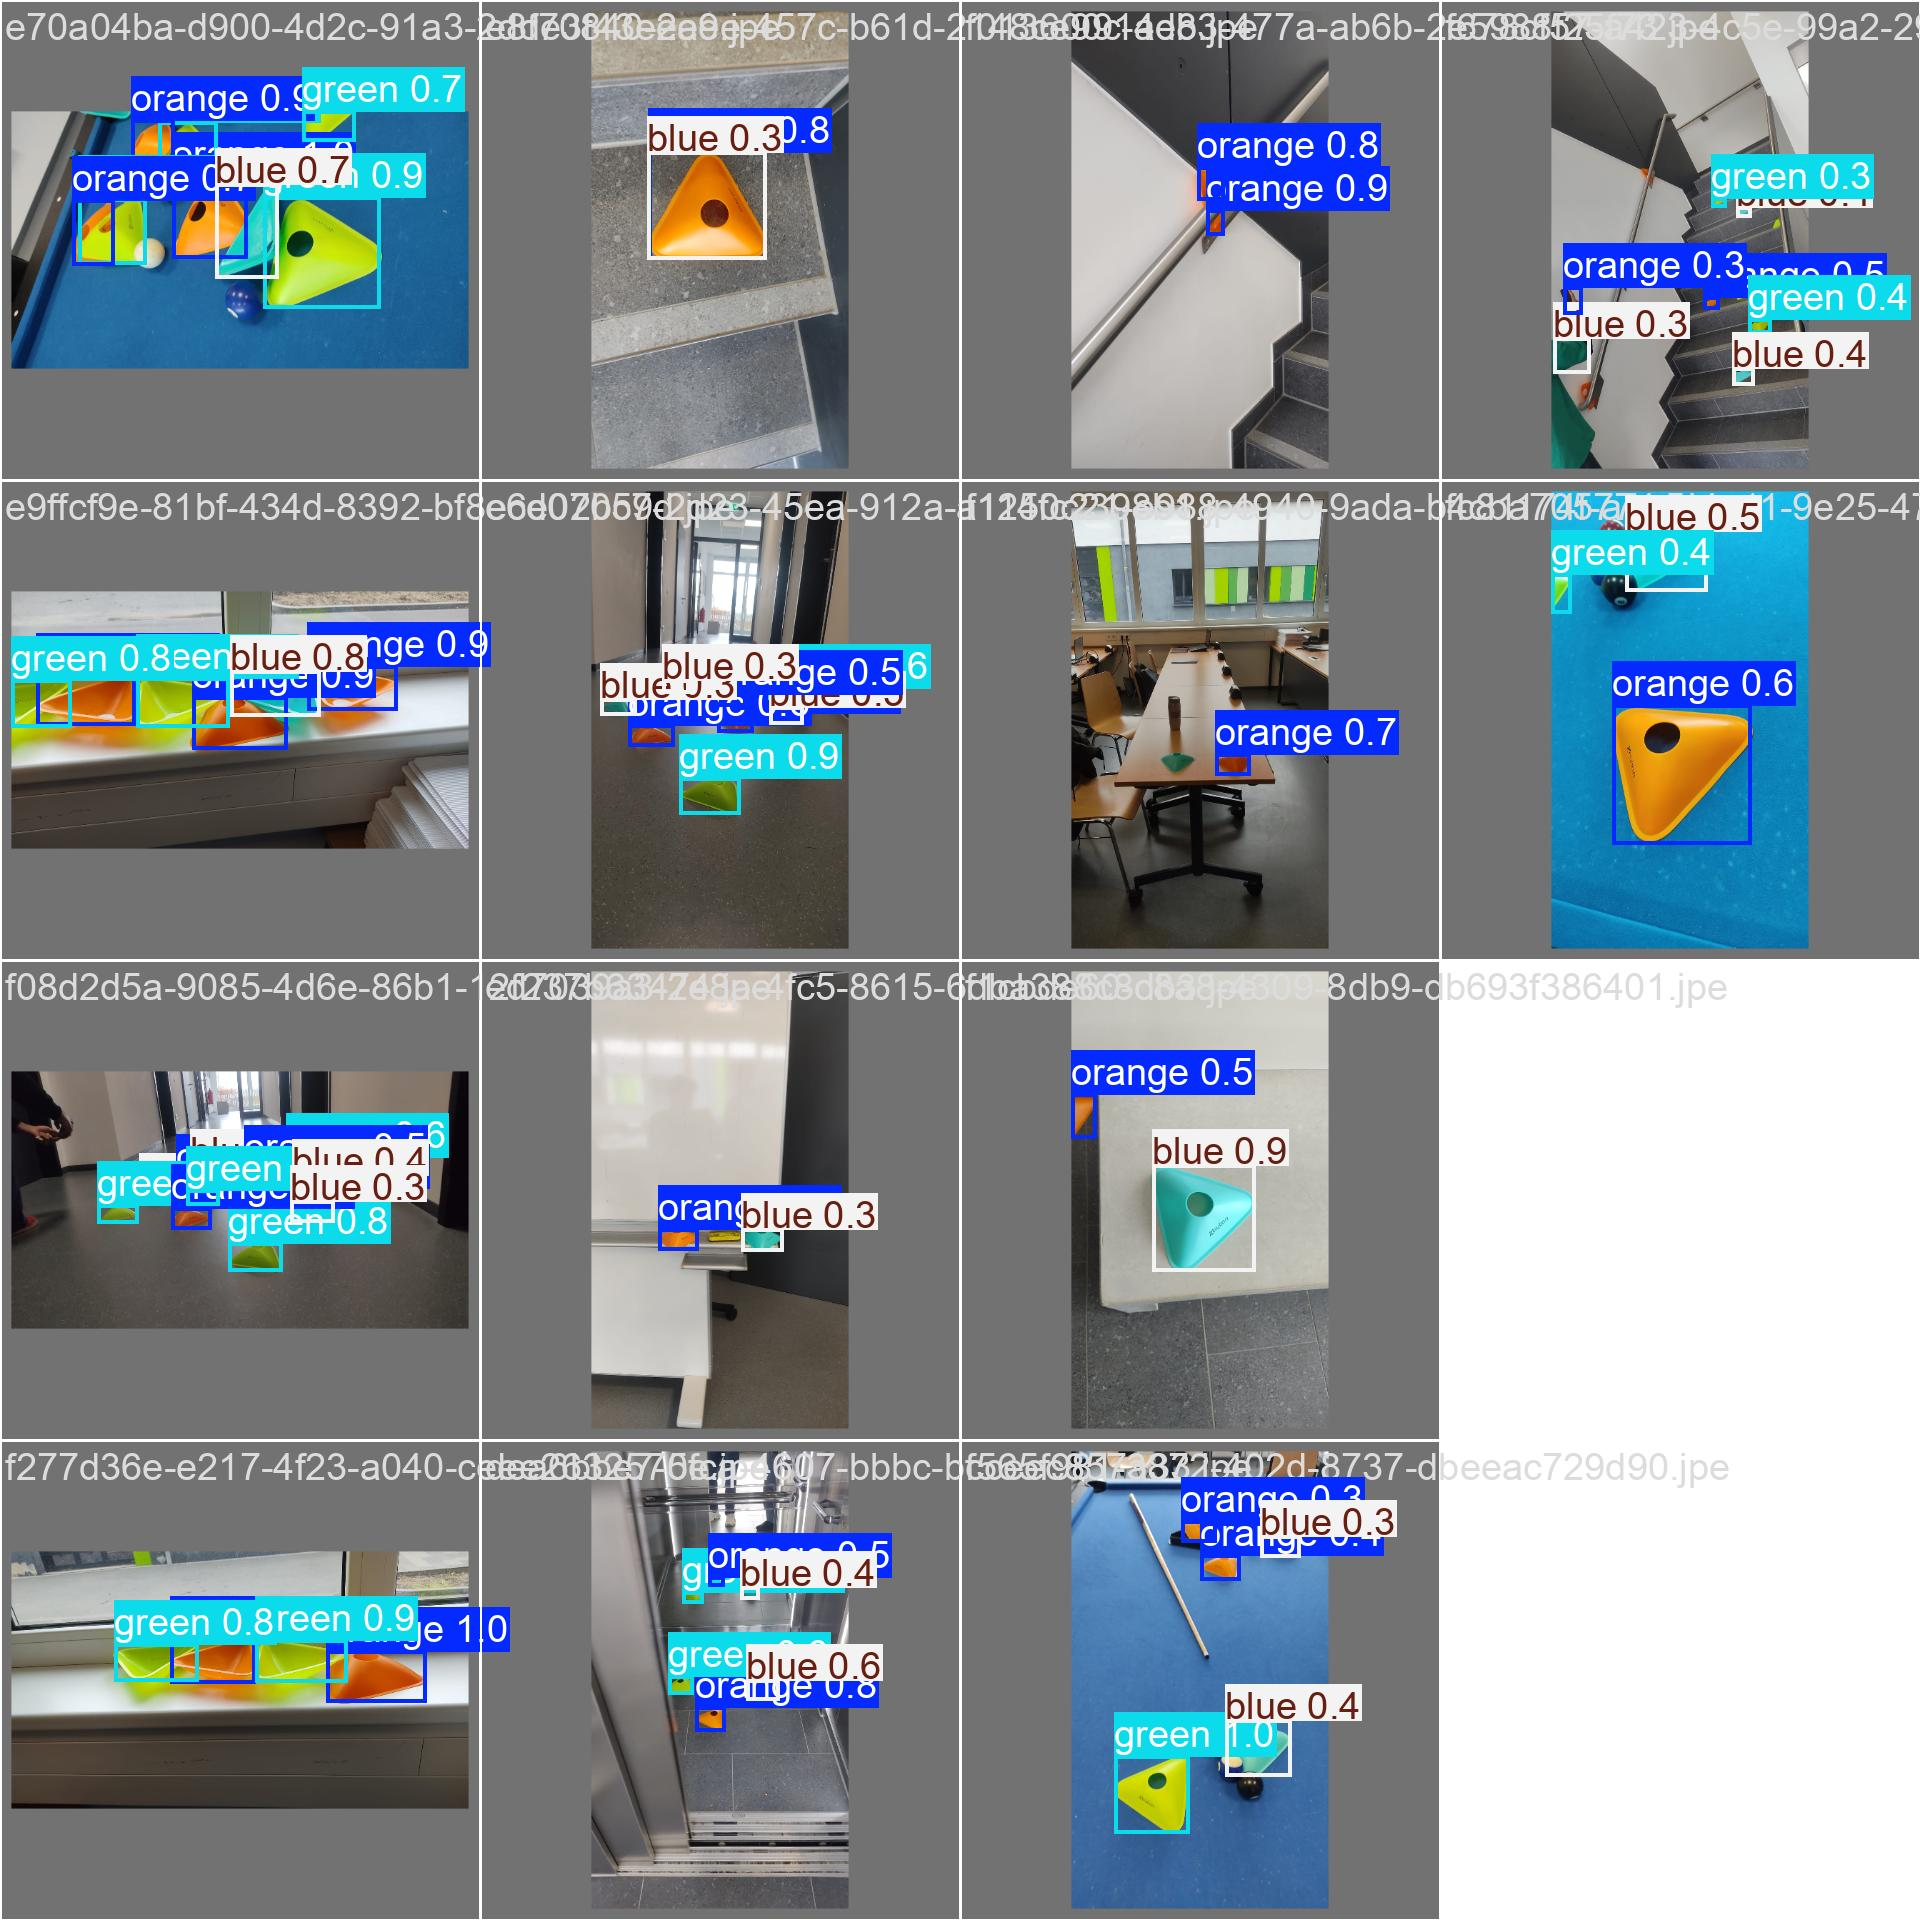

In [12]:
# Show the confusion matrix to see if it's mixing up colors
from IPython.display import Image, display

# Replace the path if your 'runs' folder is in a different subdirectory
display(Image(filename='/home/boaz/yolo_env/workspace/runs/detect/train4/confusion_matrix.png'))

# Path to your successful training run
results_path = '/home/boaz/yolo_env/workspace/runs/detect/train4'

print("--- Ground Truth (Your Labels) ---")
display(Image(filename=os.path.join(results_path, 'val_batch0_labels.jpg')))

print("\n--- Model Predictions ---")
display(Image(filename=os.path.join(results_path, 'val_batch0_pred.jpg')))

Run Inference on New Images

In [ ]:
# Load your trained weights
my_model = YOLO("runs/detect/train/weights/best.pt")

# Run detection
results = my_model.predict(source="/test_image.jpg", conf=0.5)

# Show the result
for r in results:
    r.show() # This will pop up the image with bounding boxes